<a href="https://colab.research.google.com/github/mamtasharma1/Automation_Mamta/blob/main/Mamta_Sharma_Assignment2_AIModelBuilder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BDA300 – Assignment 2
## AI-Assisted Cluster and Classification Model Builder
**Dataset:** Iris Dataset  
**Tool:** ChatGPT (GPT-5.6 Sol)  
**Date:** September 19, 2026

### AI Assistance Declaration
I used ChatGPT (GPT-5.6 Sol) to help me understand the assignment, draft Python code, add comments, and suggest model evaluation steps. I reviewed the code, ran the models, checked the outputs, and compared the results myself. The prompts are documented below. I am responsible for the accuracy and originality of this work.


# Step 1 – Set Up the Environment
**Seed prompt:** *Write Python code in scikit-learn to load the Iris dataset and display its structure.*  
**Refinement:** *Add simple comments to explain each step.*

I loaded the Iris dataset and converted it to a pandas DataFrame so I could inspect it more easily.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, adjusted_rand_score

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = df["target"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

display(df.head())
print("Dataset shape:", df.shape)
print("\nSpecies distribution:")
print(df["species"].value_counts())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Dataset shape: (150, 6)

Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### Dataset Structure
The Iris dataset contains 150 flower records from three species: setosa, versicolor, and virginica. The four features are sepal length, sepal width, petal length, and petal width. Each species has 50 records.

**Validation prompt:** *Explain in plain English what each feature and label represents.*


# Step 2 – Classification Models
I used a Decision Tree and K-Nearest Neighbors (KNN). Both models use the same train/test split so the comparison is fair.

**Seed prompt:** *Create Python code to train and test Decision Tree and KNN classifiers on Iris.*  
**Refinement:** *Add accuracy, confusion matrix, classification report, and a fixed random state.*


In [2]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))


Training records: 120
Testing records: 30


In [3]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_accuracy, 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("\nClassification Report:\n",
      classification_report(y_test, dt_pred, target_names=iris.target_names))


Decision Tree Accuracy: 0.9333

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



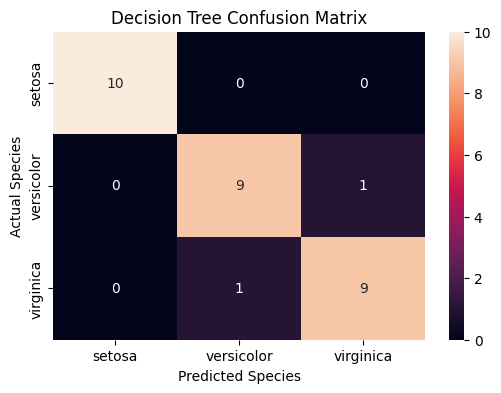

In [4]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt="d",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", round(knn_accuracy, 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, knn_pred))
print("\nClassification Report:\n",
      classification_report(y_test, knn_pred, target_names=iris.target_names))


KNN Accuracy: 0.9333

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



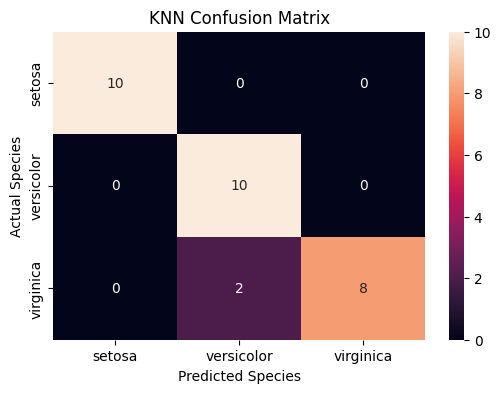

In [6]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt="d",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()


## Parameter Change
I changed the Decision Tree `max_depth` to see how limiting tree complexity affects test accuracy.

**Prompt:** *Modify max_depth and compare the accuracy with the original Decision Tree.*


In [7]:
results = []
for depth in [1, 2, 3, 4, 5, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append([str(depth), acc])

depth_results = pd.DataFrame(results, columns=["max_depth", "test_accuracy"])
display(depth_results)


,max_depth,test_accuracy
0,1,0.666667
1,2,0.933333
2,3,0.966667
3,4,0.933333
4,5,0.933333
5,None,0.933333


### My Classification Observation
The Decision Tree is easy to understand because it creates decision rules, while KNN classifies a flower based on nearby examples. I standardized the data for KNN because it uses distances. Changing `max_depth` also showed me that model settings matter: a tree that is too shallow may underfit, while an unrestricted tree can become more complex than needed.

**Critique prompt:** *Does the model appear overfitted? Compare training and testing accuracy.*


In [8]:
dt_train_accuracy = accuracy_score(y_train, dt_model.predict(X_train))
print("Decision Tree training accuracy:", round(dt_train_accuracy, 4))
print("Decision Tree testing accuracy:", round(dt_accuracy, 4))
print("Difference:", round(dt_train_accuracy - dt_accuracy, 4))


Decision Tree training accuracy: 1.0
Decision Tree testing accuracy: 0.9333
Difference: 0.0667


# Step 3 – K-Means Clustering
K-Means is unsupervised, so the true species labels are not used to create the clusters. I used three clusters because Iris contains three known species and standardized the four features before clustering.

**Seed prompt:** *Generate Python code for K-Means clustering on Iris and plot the clusters.*  
**Refinement:** *Standardize features, label the axes, add a title, and calculate adjusted_rand_score.*


In [9]:
cluster_scaler = StandardScaler()
X_scaled = cluster_scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

ari = adjusted_rand_score(y, clusters)
print("Adjusted Rand Score (ARI):", round(ari, 4))


Adjusted Rand Score (ARI): 0.6201


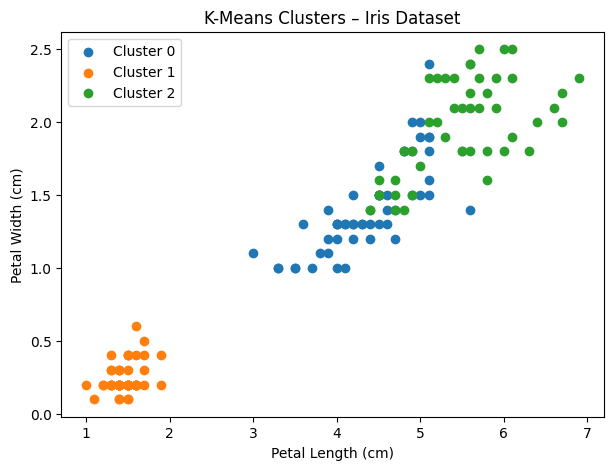

In [10]:
plt.figure(figsize=(7,5))
for cluster_id in range(3):
    mask = clusters == cluster_id
    plt.scatter(X[mask,2], X[mask,3], label=f"Cluster {cluster_id}")

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("K-Means Clusters – Iris Dataset")
plt.legend()
plt.show()


### Clustering Reflection
The Adjusted Rand Index compares the K-Means groups with the real species. A higher ARI means the cluster grouping is closer to the actual labels. I did not expect a perfect result because K-Means only sees numerical distances and does not know the species names. Also, the plot shows two features even though the clustering model uses all four.

**Critique prompt:** *Explain how well the clusters align with the real species and give one limitation.*


# Step 4 – Final Reflection
After running both classifiers, I will compare their test accuracies and confusion matrices to see which performed better on this split. I learned that AI can create useful starter code quickly, but I still need to understand and verify it. One issue I noticed is that basic AI-generated KNN code may leave out feature scaling, even though KNN depends on distance, so I added `StandardScaler`. Results can also change with the data split and model settings, so documenting the random state and parameters is important for reproducibility. An ethical risk is trusting AI-generated analysis without checking whether the data, assumptions, and model are appropriate.


# Appendix – AI Prompts Used
**Tool:** ChatGPT (GPT-5.6 Sol)  
**Date:** September 19, 2026

1. Write Python code in scikit-learn to load the Iris dataset and display its structure.
2. Add simple comments to explain each step.
3. Explain in plain English what each feature and label represents.
4. Create Python code to train and test Decision Tree and KNN classifiers on Iris.
5. Add accuracy, confusion matrix, classification report, and a fixed random state.
6. Modify the Decision Tree max_depth parameter and compare accuracy.
7. Does the model appear overfitted? Compare training and testing accuracy.
8. Generate Python code for K-Means clustering on Iris and plot the clusters.
9. Standardize the features, label axes, add a title, and calculate adjusted_rand_score.
10. Explain how well the clusters align with the real species and give one limitation.

### Verification
I checked that the dataset loaded correctly, both classifiers produced predictions, confusion matrices matched the test data, and K-Means returned three clusters. I compared the actual outputs instead of accepting an AI conclusion. I also used scaling for KNN and K-Means and fixed random states to make the workflow reproducible.
